Initializing Radar Parameters...
Loading ADC Data...
Reshaping to Chirps...
LVDS: (4096, 800)
Selecting RX and Frames...
adc all: (4, 819200)
(4, 200, 4096)


/var/folders/hm/7p8fzz2x2y10pbydpxcs7vw00000gn/T/ipykernel_38061/3184630423.py:206: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(frame_path)
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1256, 488) to (1264, 496) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Beamformed shape: (4096, 64, 256)
ret_val: (200, 4096)
processed adc (200, 2048)
Performing Range FFT...


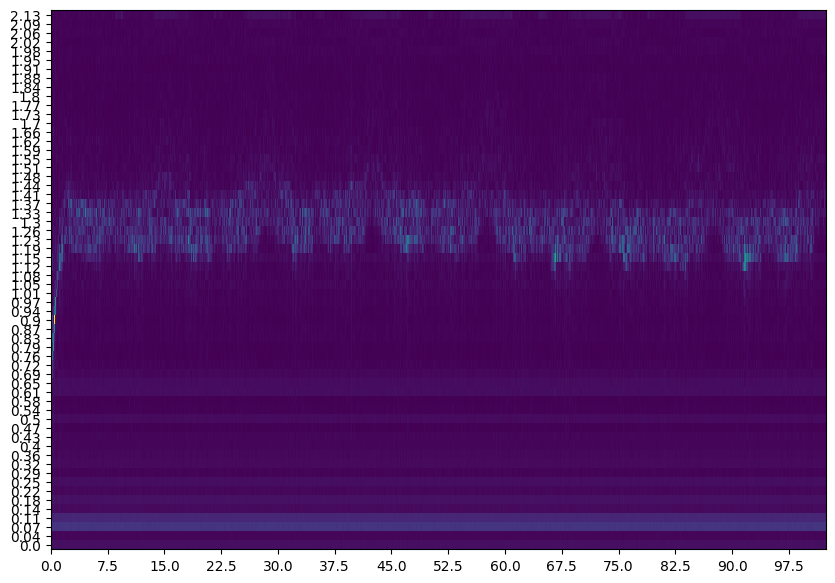

fft_abs (2048, 256)
Selected range bin = 17 (0.61 m)
Extracting Phase...


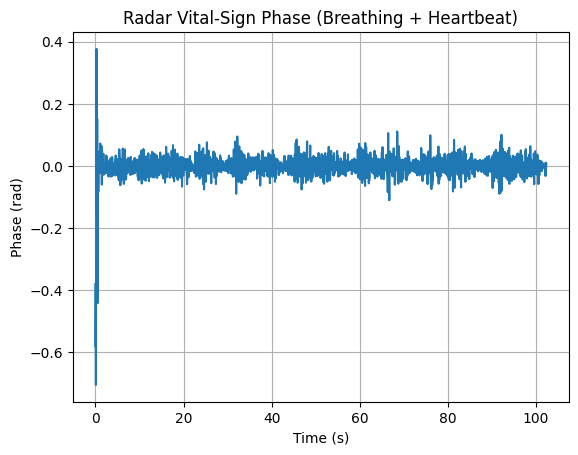

Performing EEMD Decomposition (this may take a moment)...
Plotting Results...


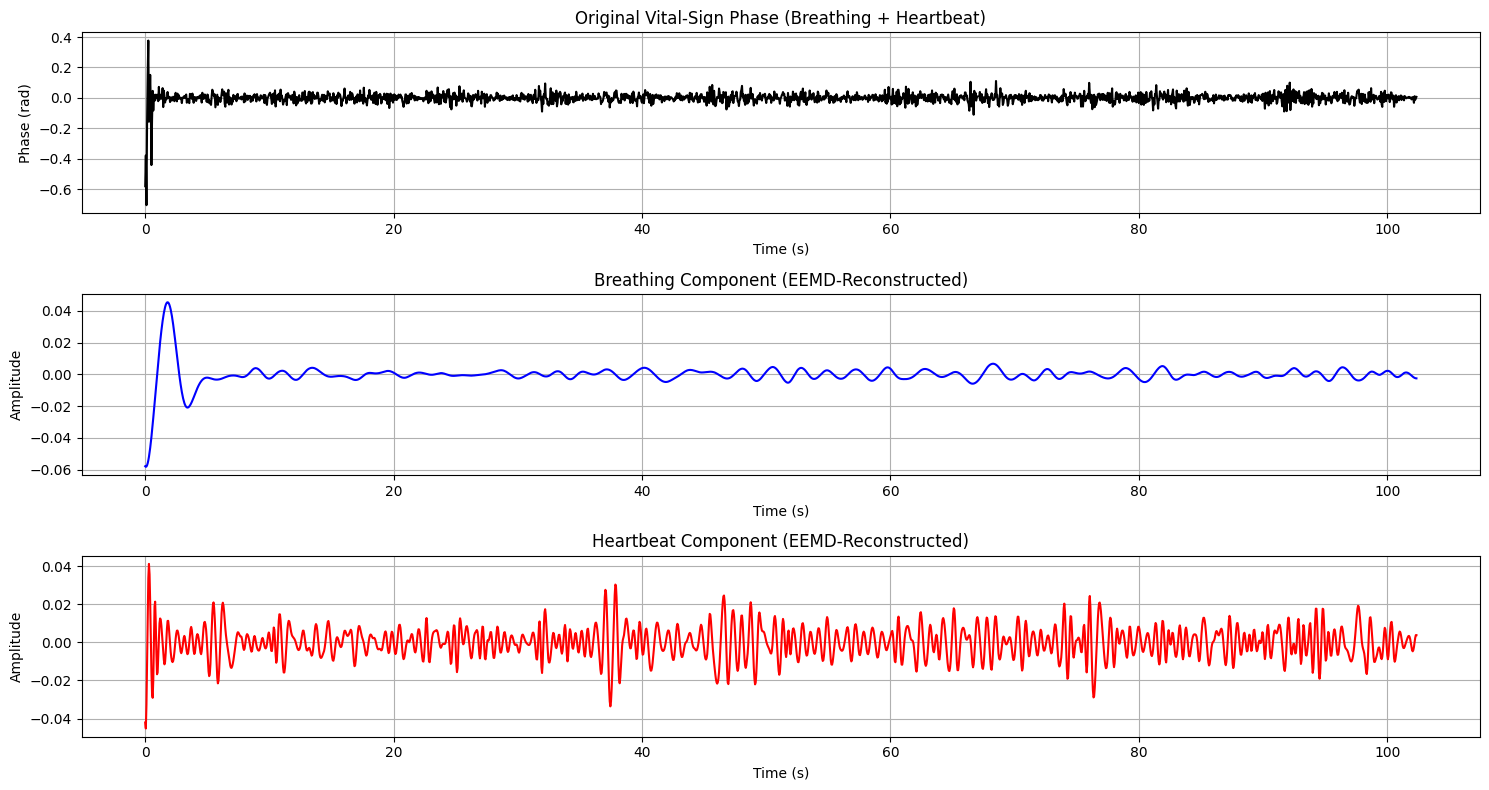

Count breaths: 34; Breathing rate: 19.93160723009282/min.
Count heartbeat: 139; Heart rate: 81.48510014655594/min.


In [31]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve, find_peaks
from scipy.io import loadmat
import numpy as np
import imageio
import os

from PyEMD import EEMD
def count_peaks_robust(vector, min_height=None, min_dist=None):
    """
    Counts peaks using scipy.signal.find_peaks.
    
    Args:
        vector (array-like): The input 1D signal.
        min_height (float): peaks below this value are ignored.
        min_dist (int): minimum number of samples between peaks.
        
    Returns:
        count (int): Number of peaks found.
        peaks (ndarray): Indices of the peaks.
    """
    # find_peaks returns a tuple: (indices, properties_dict)
    peaks, _ = find_peaks(vector, height=min_height, distance=min_dist)
    
    return len(peaks), peaks

# ===================== CLASS TO HOLD PARAMETERS =====================
class RadarParams:
    def __init__(self):
        # data
        self.data_cube = None
        self.distances = None

        # ADC Config
        self.numADCSamples = 200
        self.numADCBits = 16
        self.numTX = 1
        self.numRX = 4
        self.isReal = 0

        #Representation
        self.saveVid=True
        
        #Beamforming related
        self.breamformed_data = None
        self.beamform = True
        self.vartheta =  np.pi / 180

        # Radar constants
        self.Fs_adc = 4e6
        self.c = 3e8
        self.slope = 64.985e12
        self.startFreq = 77e9
        self.lambda_ = self.c / self.startFreq

        # Chirp / frame timing
        self.framePeriod = 0.05
        self.Fs_vital = 1 / self.framePeriod

        # FFT
        self.RangeFFT = 256
        self.AngleFFT=64 # number of angle FFT bins

        # File Config
        self.binIdx = 1
        # Adjust path as necessary for your local machine
        self.dataSubDir = os.path.join('myDatRepoFormat', 'manavjeet_moving')

def load_adc_data(P):
    """Loads raw binary data from file."""
    # Construct path based on current script location
    cur_dir = os.getcwd() 
    data_dir = os.path.join(cur_dir, P.dataSubDir)
    file_name = f'data{P.binIdx}.bin'
    full_path = os.path.join(data_dir, file_name)

    if not os.path.exists(full_path):
        raise FileNotFoundError(f"File not found: {full_path}")

    # Read binary data as int16
    adc_data = np.fromfile(full_path, dtype=np.int16)

    # Handle 2's complement if bits < 16 (Not strictly needed for 16-bit, but kept for logic)
    if P.numADCBits != 16:
        lmax = 2**(P.numADCBits - 1) - 1
        mask = adc_data > lmax
        adc_data[mask] = adc_data[mask] - 2**P.numADCBits

    return adc_data

def beamform(data_cube, P):
    # data_cube shape: [num_rx, num_samples, num_chirps]
    print(data_cube.shape)
    num_chirps=data_cube.shape[2]
    all_chirp_beamformed_data=np.zeros([num_chirps, P.AngleFFT, P.RangeFFT], dtype=np.complex128)
    # FFT data is transposed. FFT shape: [num_rx, num_chirps, num_samples]
    fft_data, fft_abs, t = rangeFFT(data_cube, P)
    
    deltaR = P.Fs_adc * P.c / (2 * P.slope * P.RangeFFT)
    # heatmap(fft_abs[3,:,:30],np.arange(P.RangeFFT) * deltaR, t)
    

    for chirp_no in range(num_chirps):
        # Let's process the first chirp for a Range-Angle Map
        data_slice = fft_data[:, chirp_no,: ]

        # 1. Apply windowing across the RX dimension (axis 0 here)
        window = np.hamming(P.numRX).reshape(P.numRX, 1)
        windowed_data = data_slice * window

        # 2. Zero-pad for better angular resolution (e.g., to 64 points)
        # FFT across the RX dimension (axis 0)
        beamformed_data = np.fft.fft(windowed_data, n=P.AngleFFT, axis=0)

        # 3. Shift the zero-frequency component to the center
        beamformed_data = np.fft.fftshift(beamformed_data, axes=0)

        # 4. Convert to Magnitude (Power)
        range_angle_map = np.abs(beamformed_data)
        all_chirp_beamformed_data[chirp_no,:,:]=beamformed_data
        # print("beamformed_data", beamformed_data.shape) 
        # break
        
    _lambda=3e8/79e9

    # 1. Create centered bin indices: [-N/2, ..., N/2 - 1]
    # This corresponds to what np.fft.fftshift does to your data
    bin_indices = np.arange(-P.AngleFFT//2, P.AngleFFT//2)

    # 2. Calculate the term inside the arcsin
    # Note: we use (d * num_angle_bins) as the denominator
    rescale_factor = (bin_indices * _lambda) / (_lambda/2 * P.AngleFFT)

    # 3. Clip the values to avoid float precision errors (like 1.00000000001)
    rescale_factor = np.clip(rescale_factor, -1.0, 1.0)

    # 4. Convert to angles (radians)
    angles_deg = np.rad2deg(np.arcsin(rescale_factor))

    
    distances=np.arange(P.RangeFFT) * deltaR
    P.distances=distances
    idxes=np.arange(0,60)
    y_idxes = np.arange(0,P.AngleFFT,8)
    
    if not P.saveVid:

        ## Plotting only one chirp
        plt.figure(figsize=[15,5])
        plt.imshow(np.abs(all_chirp_beamformed_data[0,:,idxes].T), interpolation='none', aspect='auto',)
        # plt.xticks(distances[:30])
        plt.xticks(idxes, np.round(distances[idxes],2))
        # plt.yticks(y_idxes, np.round(angles_deg[y_idxes],2))
        plt.xlabel("Distance bin (m)")
        plt.ylabel("Beamform angle (deg)")
        ax=plt.gca()
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
        plt.show()
    else: 
        # Plotting and saving chirp gifs
        os.makedirs("frames", exist_ok=True)

        frame_paths = []

        for chirp_no in range(num_chirps):
        # for chirp_no in range(100):
            plt.figure(figsize=(15, 5))

            plt.imshow(
                np.abs(all_chirp_beamformed_data[chirp_no, :, idxes].T),
                interpolation="none",
                aspect="auto"
            )

            plt.xticks(idxes, np.round(distances[idxes], 2))
            plt.yticks(y_idxes, np.round(angles_deg[y_idxes],2))
            
            plt.xlabel("Distance bin (m)")
            plt.ylabel("Beamform angle (deg)")
            plt.title(f"Chirp {chirp_no}, Time: {t[chirp_no]}s", loc='left')
            ax=plt.gca()
            plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
            frame_path = f"frames/chirp_{chirp_no}.png"
            plt.savefig(frame_path, dpi=100, bbox_inches="tight")
            plt.close()

            frame_paths.append(frame_path)

        # with imageio.get_writer(f"beamforming_{P.binIdx}.gif", mode="I", duration=0.4) as writer:
        #     for frame_path in frame_paths:
        #         image = imageio.imread(frame_path)
        #         writer.append_data(image)
        

        fps = 1 / (t[2]-t[1])  # Calculate FPS based on time difference between chirps

        with imageio.get_writer(
            f"{P.dataSubDir}/beamforming_{P.binIdx}.mp4",
            fps=fps,
            codec="libx264",
            quality=8
        ) as writer:
            for frame_path in frame_paths:
                image = imageio.imread(frame_path)
                writer.append_data(image)
    
    return all_chirp_beamformed_data

    # 3. Execute for both sources
    # To get Phi1, we must NULL Phi2 (target_null = theta2)
    phi1_extracted = apply_null_steering(theta2_rad)
    
    # To get Phi2, we must NULL Phi1 (target_null = theta1)
    phi2_extracted = apply_null_steering(theta1_rad)
    
    return phi1_extracted, phi2_extracted

# --- Example Usage ---
# Assuming you have a data_cube of shape (4, 128, 64)
# num_rx = 4, samples = 128, chirps = 64
# signal_1 at -10 degrees, signal_2 at +30 degrees

# dummy_data = np.random.randn(4, 128, 64) + 1j * np.random.randn(4, 128, 64)
# phi1, phi2 = differential_null_steering(dummy_data, -10, 30)


def reshape_to_chirps(adc_data, P):
    """
    Handles the complex interleaving specific to TI DCA1000 data.
    """
    if P.isReal:
        samples_per_chirp = P.numADCSamples * P.numRX
        num_chirps = len(adc_data) // samples_per_chirp
        adc_data = adc_data[:num_chirps * samples_per_chirp]
        
        # Reshape to (samples_per_chirp, num_chirps) then transpose
        LVDS = np.reshape(adc_data, (num_chirps, samples_per_chirp))
    else:
        # Complex data: 2 * Samples * RX
        samples_per_chirp = 2 * P.numADCSamples * P.numRX
        num_chirps = len(adc_data) // samples_per_chirp
        adc_data = adc_data[:num_chirps * samples_per_chirp]

        # Vectorized Complex Combination (replaces the slow MATLAB for-loop)
        # MATLAB Logic:
        # i   -> real1, i+2 -> imag1
        # i+1 -> real2, i+3 -> imag2
        
        raw_0 = adc_data[0::4] # Real 1
        raw_1 = adc_data[1::4] # Real 2
        raw_2 = adc_data[2::4] # Imag 1
        raw_3 = adc_data[3::4] # Imag 2

        comp_1 = raw_0 + 1j * raw_2
        comp_2 = raw_1 + 1j * raw_3
        
        # Interleave comp_1 and comp_2 to match MATLAB 'tmp' structure
        # Stack them: [[c1_0, c1_1...], [c2_0, c2_1...]]
        combined = np.vstack((comp_1, comp_2))
        
        # Flatten column-major (Fortran style) to interleave: c1_0, c2_0, c1_1, c2_1...
        tmp = combined.reshape(-1, order='F')
        
        # Reshape to Matrix: Rows = Samples*RX, Cols = Chirps
        # MATLAB: reshape(tmp, P.numADCSamples*P.numRX, numChirps).';
        # Python reshape is Row-major by default, so we be careful.
        # We want numChirps rows eventually? MATLAB's result is (numChirps, numSamples*RX)
        
        # Let's match MATLAB dimensions:
        # MATLAB reshape inputs: (rows, cols).
        # We reshape to (Samples*RX, Chirps) first, then Transpose.
        LVDS = tmp.reshape((P.numADCSamples * P.numRX, num_chirps), order='F').T
        print("LVDS:",LVDS.shape)
    return LVDS

def select_rx_and_chirps(LVDS, P):
    """
    Rearranges LVDS data into (RX, Chirp, Sample) structure and selects specific frames.
    """
    
    num_chirps = LVDS.shape[0]
    
    # Create placeholder for all ADC data separated by RX
    # MATLAB: adcAll = zeros(P.numRX, numChirps*P.numADCSamples);
    adc_all = np.zeros((P.numRX, num_chirps * P.numADCSamples), dtype=complex)

    # In Python, LVDS is (numChirps, numADCSamples*numRX)
    # We need to extract the samples for each RX.
    # The data is usually interleaved: Sample1_RX1, Sample1_RX2, Sample1_RX3...
    # But based on the MATLAB code: 
    # LVDS(k, (rx-1)*N+1 : rx*N) implies blocks of samples per RX.
    
    for rx in range(P.numRX):
        # Calculate start/end indices for columns in LVDS
        col_start = rx * P.numADCSamples
        col_end   = (rx + 1) * P.numADCSamples
        
        # Extract for all chirps
        # Current shape: (Chirps, Samples)
        rx_data = LVDS[:, col_start:col_end]
        
        # Flatten row-wise to fit into the long 1D array per RX
        adc_all[rx, :] = rx_data.reshape(-1)

    print("adc all:",adc_all.shape)
    
    # ---  Insert beamforming ---
    data_cube = np.zeros([P.numRX, P.numADCSamples, num_chirps],dtype=np.complex128)
    idx=0
    for chirp_no in range(num_chirps):
        for sample_no in range(P.numADCSamples):
            data_cube[0][sample_no][chirp_no]=adc_all[0][idx]
            data_cube[1][sample_no][chirp_no]=adc_all[1][idx]
            data_cube[2][sample_no][chirp_no]=adc_all[2][idx]
            data_cube[3][sample_no][chirp_no]=adc_all[3][idx]
            idx+=1
    P.data_cube = data_cube
    if P.beamform:
        P.breamformed_data = beamform(data_cube,P)
        print("Beamformed shape:", P.breamformed_data.shape)
    # -- -- --
    
    # MATLAB: retVal = reshape(adcAll(1,:), P.numADCSamples, numChirps);
    # Take RX 1 (index 0)
    # Reshape to (Samples, Chirps)
    ret_val = adc_all[0, :].reshape((P.numADCSamples, num_chirps), order='F')
    print("ret_val:", ret_val.shape)
    
    # Select Chirps (1st chirp per frame)
    # Frames = Chirps / 2 (assuming 2 chirps per frame based on MATLAB code)
    num_frames = num_chirps // 2
    
    # Take every 2nd column (chirp)
    process_adc = ret_val[:, 0::2]
    
    # Ensure we stick to numFrames count
    process_adc = process_adc[:, :num_frames]
    print("processed adc", process_adc.shape)
    return process_adc

def heatmap(fft_data,distances,t):
    plt.figure(figsize=(10,7))
    plt.imshow((fft_data.T), aspect='auto', cmap='viridis', origin='lower',  interpolation='nearest')
    yticks = np.arange(fft_data.shape[1])
    ytick_labels = np.round(distances[:fft_data.shape[1]],2)
    plt.yticks(yticks, ytick_labels)
    
    xticks = np.arange(fft_data.shape[0])
    plt.xticks(xticks[::150], np.round(t[::150],2))
    
    plt.show()
    
# def beamformFFT(fft_abs):
#     num_angle_bins = 64
#     all_chirp_beamformed_data=np.zeros([rangeFFTAcrossChirps.shape[0], num_angle_bins, rangeFFTAcrossChirps.shape[2]], dtype=np.complex128)

def rangeFFT(adc, P):
    if len(adc.shape)==2 or (len(adc.shape)==3 and adc.shape[0]==1):
        # FFT along axis 0 (samples), n=RangeFFT
        # MATLAB: fft(adc, P.RangeFFT, 1).'; -> Transpose at end
        fft_data = np.fft.fft(adc, P.RangeFFT, axis=0).T
        fft_abs = np.abs(fft_data)
        t = np.arange(len(fft_abs)) / P.Fs_vital
    else:
        fft_data=np.zeros([adc.shape[0],adc.shape[2],P.RangeFFT],dtype=np.complex128)
        fft_abs=np.zeros([adc.shape[0],adc.shape[2],P.RangeFFT],dtype=float)
        for rx in range(adc.shape[0]):
            fft_data[rx,:,:] = np.fft.fft(adc[rx,:,:], P.RangeFFT, axis=0).T
            fft_abs[rx,:,:] = np.abs(fft_data[rx,:,:])
            
        t = np.arange(len(fft_abs[0])) / P.Fs_vital / 2
    return fft_data, fft_abs, t
    
def select_target_range_bin(adc, P):
    """
    Performs Range FFT and selects the bin with max energy in specific distance.
    """
    if P.breamformed_data is None:
        fft_data, fft_abs, t = rangeFFT(adc, P)
    else:
        fft_data = P.breamformed_data[::2,30,:]
        fft_abs = np.abs(fft_data)
        t = np.arange(len(fft_abs)) / P.Fs_vital
        
        
    deltaR = P.Fs_adc * P.c / (2 * P.slope * P.RangeFFT)
        # Plotting heatmap of range FFT.
    heatmap(fft_abs[:,:60],np.arange(P.RangeFFT) * deltaR, t)
    print("fft_abs", fft_abs.shape)

    range_energy = np.zeros(P.RangeFFT)

    # Range selection loop
    for r in range(P.RangeFFT):
        d = r * deltaR # Python 0-indexed, so r corresponds to (r-1) in MATLAB logic approx
        if 0.5 < d < 1:
            # Sum energy across time (columns) for this range bin
            range_energy[r] = np.sum(fft_abs[:, r])

    max_bin = np.argmax(range_energy)
    
    # return max_bin, deltaR, fft_data
    return 17, deltaR, fft_data

def extract_vital_phase(bin_signal):
    """
    Extracts phase, unwraps, differentiates, and smooths.
    """
    phase_raw = np.angle(bin_signal)
    phase_unwrap = np.unwrap(phase_raw)
    
    # Diff (prepending 0 to maintain length)
    phase_diff = np.diff(phase_unwrap, prepend=0)
    
    # Smooth data (Moving Mean window 5)
    # Using convolution for moving mean
    window_size = 5
    kernel = np.ones(window_size) / window_size
    phi = convolve(phase_diff, kernel, mode='same')
    
    return phi

def extract_breath_heart_eemd(phi, Fs_vital):
    """
    Decomposes phase signal using EEMD and reconstructs Breath/Heart signals.
    """
    phi = phi.flatten()
    N = len(phi)

    # EEMD Parameters
    NE = 100 #NE=Number of Ensembles
    noise_amp = 0.2 * np.std(phi)
    
    # Initialize EEMD
    eemd = EEMD(trials=NE, noise_width=noise_amp) # Intrinsic Mode Function == IMF
    # Note: max_imf is strictly not a parameter in standard PyEMD call usually,
    # but we can slice the result if needed. 
    
    # Run EEMD
    # IMFs will be returned as (num_imfs, N)
    imfs = eemd.eemd(phi)
    
    # Limit IMFs to 10 if we have more
    if imfs.shape[0] > 10:
        imfs = imfs[:10, :]

    # Frequency Analysis
    f_axis = np.arange(N) * Fs_vital / N
    
    breath_idx = []
    heart_idx = []

    # imfs.shape[0] is number of IMFs
    for k in range(imfs.shape[0]):
        IMFk = imfs[k, :]
        
        F = np.abs(np.fft.fft(IMFk))
        # Half spectrum
        half_N = N // 2
        Fh = F[:half_N]
        fh = f_axis[:half_N]
        
        # Find peak
        idx = np.argmax(Fh)
        f_peak = fh[idx]
        
        # Band classification
        if 0.1 <= f_peak <= 0.5:
            breath_idx.append(k)
        elif 0.8 <= f_peak <= 2.0:
            heart_idx.append(k)

    # Reconstruction
    breath_wave = np.zeros(N)
    heart_wave = np.zeros(N)

    if breath_idx:
        breath_wave = np.sum(imfs[breath_idx, :], axis=0)
    
    if heart_idx:
        heart_wave = np.sum(imfs[heart_idx, :], axis=0)

    return breath_wave, heart_wave

def plot_vital_components(t, phi, breath_wave, heart_wave):
    plt.figure(figsize=(15, 8))

    plt.subplot(3, 1, 1)
    plt.plot(t, phi, 'k', linewidth=1.5)
    plt.grid(True)
    plt.xlabel('Time (s)')
    plt.ylabel('Phase (rad)')
    plt.title('Original Vital-Sign Phase (Breathing + Heartbeat)')

    plt.subplot(3, 1, 2)
    plt.plot(t, breath_wave, 'b', linewidth=1.5)
    plt.grid(True)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title('Breathing Component (EEMD-Reconstructed)')

    plt.subplot(3, 1, 3)
    plt.plot(t, heart_wave, 'r', linewidth=1.5)
    plt.grid(True)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title('Heartbeat Component (EEMD-Reconstructed)')

    plt.tight_layout()
    plt.show()

# ===================== MAIN EXECUTION =====================
# if __name__ == "__main__":         
print("Initializing Radar Parameters...")
P = RadarParams()

try:
    print("Loading ADC Data...")
    adcData = load_adc_data(P)

    print("Reshaping to Chirps...")
    LVDS = reshape_to_chirps(adcData, P)

    print("Selecting RX and Frames...")
    process_adc = select_rx_and_chirps(LVDS, P)

    print("Performing Range FFT...")
    max_bin, deltaR, fft_data = select_target_range_bin(process_adc, P)
    print(f"Selected range bin = {max_bin} ({max_bin * deltaR:.2f} m)")

    print("Extracting Phase...")
    # Note: fft_data is (Chirps x RangeBins), so we slice column max_bin
    phi = extract_vital_phase(fft_data[:, max_bin])

    # Time axis
    t = np.arange(len(phi)) / P.Fs_vital

    # Quick Plot of Phase
    plt.figure()
    plt.plot(t, phi, linewidth=1.5)
    plt.grid(True)
    plt.xlabel('Time (s)')
    plt.ylabel('Phase (rad)')
    plt.title('Radar Vital-Sign Phase (Breathing + Heartbeat)')
    plt.show()

    print("Performing EEMD Decomposition (this may take a moment)...")
    breath_wave, heart_wave = extract_breath_heart_eemd(phi, P.Fs_vital)

    print("Plotting Results...")
    plot_vital_components(t, phi, breath_wave, heart_wave)
    
    count_breaths,_=count_peaks_robust(breath_wave, min_dist=40)
    count_hb,_=count_peaks_robust(heart_wave, min_dist=10)
    b_rate=count_breaths/max(t) * 60
    h_rate=count_hb/max(t) * 60
    print(f"Count breaths: {count_breaths}; Breathing rate: {b_rate}/min.")
    print(f"Count heartbeat: {count_hb}; Heart rate: {h_rate}/min.")

except FileNotFoundError as e:
    print(f"\nError: {e}")
    print("Please ensure the binary file exists in the correct 'myDatRepoFormat/manavjeet' directory structure.")
except Exception as e:
    print(f"\nAn error occurred: {e}")
    import traceback
    traceback.print_exc()

In [32]:
len(t)

2048

In [ ]:
import numpy as np

def differential_null_steering_fft(theta1_deg, theta2_deg, P, d_spacing=0.5):
    """
    Applies Differential Null-Steering on Range-FFT data.
    
    Parameters:
    - fft_data: Complex np.array of shape (num_rx, num_chirps, num_samples)
    - theta1_deg: Angle of the first source (degrees)
    - theta2_deg: Angle of the second source (degrees)
    - d_spacing: Antenna spacing in wavelengths (default 0.5)
    
    Returns:
    - phi1_fft: Separated Range-FFT for source 1 (num_chirps, num_samples)
    - phi2_fft: Separated Range-FFT for source 2 (num_chirps, num_samples)
    """
    fft_data, fft_abs, t = rangeFFT(P.data_cube, P)
    
    # 1. Setup Constants
    M = P.numRX   # num_rx is axis 0
    vartheta = np.pi / 180  # Small constant offset
    
    # Convert to radians
    theta1_rad = np.deg2rad(theta1_deg)
    theta2_rad = np.deg2rad(theta2_deg)
    
    # 2. Define Helper for Broadcasting
    # We need to broadcast weights of shape (M,) across (chirps, samples)
    # Target shape for weights: (M, 1, 1)
    
    def apply_null_steering(target_null_angle_rad):
        # Calculate alpha for the null angle
        alpha_null = 2 * np.pi * d_spacing * np.sin(target_null_angle_rad)
        
        # Create indices for antennas: shape (M, 1, 1)
        k = np.arange(M).reshape(M, 1, 1)
        
        # Generate Differential Weights (Eq 8)
        # vec1 phase: k * (alpha - vartheta)
        # vec2 phase: k * (alpha + vartheta)
        vec1 = np.exp(1j * k * (alpha_null - vartheta))
        vec2 = np.exp(1j * k * (alpha_null + vartheta))
        
        # Projection (Beamforming)
        # Summing across axis 0 (collapsing the Rx dimension)
        s1 = np.sum(vec1 * fft_data, axis=0) 
        s2 = np.sum(vec2 * fft_data, axis=0)
        
        # Phase Calibration & Subtraction (Eq 11)
        phase_shift = ((M - 1) / 2) * vartheta
        
        # Isolate the signal by cancelling the null target
        delta_s = (s2 * np.exp(1j * phase_shift)) - (s1 * np.exp(-1j * phase_shift))
        
        return delta_s

    # 3. Execute
    # To get Phi1, null Theta2
    phi1_fft = apply_null_steering(theta2_rad)
    
    # To get Phi2, null Theta1
    phi2_fft = apply_null_steering(theta1_rad)
    
    return phi1_fft, phi2_fft

# --- Usage Workflow ---
# phi1, phi2 = differential_null_steering_fft(fft_data, -10, 30)

In [34]:
P.data_cube.shape

(4, 200, 4096)

In [35]:
P.data_cube.shape[2]

4096

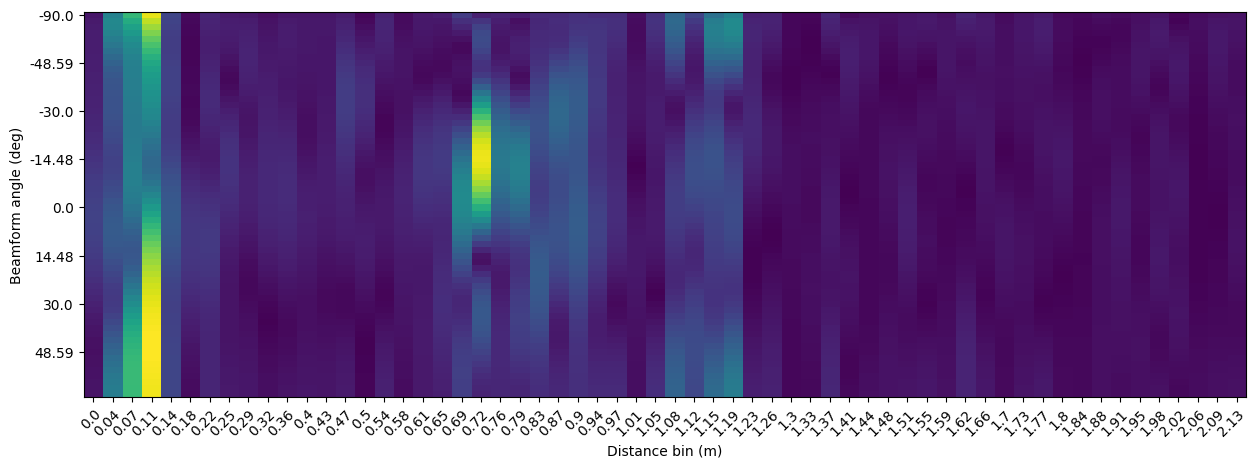

/var/folders/hm/7p8fzz2x2y10pbydpxcs7vw00000gn/T/ipykernel_38061/1759035822.py:72: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(frame_path)
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1229, 488) to (1232, 496) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [53]:
bin_indices = np.arange(-P.AngleFFT//2, P.AngleFFT//2)
_lambda=3e8/79e9
rescale_factor = (bin_indices * _lambda) / (_lambda/2 * P.AngleFFT)
rescale_factor = np.clip(rescale_factor, -1.0, 1.0)
angles_deg = np.rad2deg(np.arcsin(rescale_factor))

#range FFT data shape: [num_rx, num_chirps, num_samples] 
num_chirps=P.data_cube.shape[2]
t = np.arange(num_chirps) / P.Fs_vital/2

superres = np.zeros([num_chirps, P.AngleFFT, P.RangeFFT], dtype=np.complex128)

for angle_idx, angle in enumerate(angles_deg):
        phi1,_ = differential_null_steering_fft(angle, angle+15, P, d_spacing=0.5)
        # print(phi1.shape)
        superres[:, angle_idx, :] = phi1
chirp_no=0
idxes=np.arange(0,60)
## Plotting only one chirp
plt.figure(figsize=[15,5])
plt.imshow(np.abs(superres[chirp_no,:,idxes].T), interpolation='none', aspect='auto',)
# plt.xticks(distances[:30])
plt.xticks(idxes, np.round(P.distances[idxes],2))
ax=plt.gca()
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
y_idxes = np.arange(0,P.AngleFFT,8)
        
plt.yticks(y_idxes, np.round(angles_deg[y_idxes],2))
plt.xlabel("Distance bin (m)")
plt.ylabel("Beamform angle (deg)")
plt.show()


# Saving as a video
os.makedirs("frames", exist_ok=True)

frame_paths = []

for chirp_no in range(num_chirps):
# for chirp_no in range(100):
        plt.figure(figsize=[15,5])
        plt.imshow(np.abs(superres[chirp_no,:,idxes].T), interpolation='none', aspect='auto',)
        # plt.xticks(distances[:30])
        plt.xticks(idxes, np.round(P.distances[idxes],2))
        # plt.yticks(y_idxes, np.round(angles_deg[y_idxes],2))
        plt.xlabel("Distance bin (m)")
        plt.ylabel("Beamform angle (deg)")
        ax=plt.gca()
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
        frame_path = f"frames/chirp_{chirp_no}.png"
        plt.title(f"Chirp {chirp_no}, Time: {t[chirp_no]/2}s", loc='left')
        plt.savefig(frame_path, dpi=100, bbox_inches="tight")
        plt.close()

        frame_paths.append(frame_path)

# with imageio.get_writer(f"beamforming_{P.binIdx}.gif", mode="I", duration=0.4) as writer:
#     for frame_path in frame_paths:
#         image = imageio.imread(frame_path)
#         writer.append_data(image)


fps = 1 / ((t[2]-t[1]))  # Calculate FPS based on time difference between chirps

with imageio.get_writer(
        f"{P.dataSubDir}/superes_beamforming_{P.binIdx}.mp4",
        fps=fps,
        codec="libx264",
        quality=8
) as writer:
        for frame_path in frame_paths:
                image = imageio.imread(frame_path)
                writer.append_data(image)


(4, 200, 4096)


KeyboardInterrupt: 

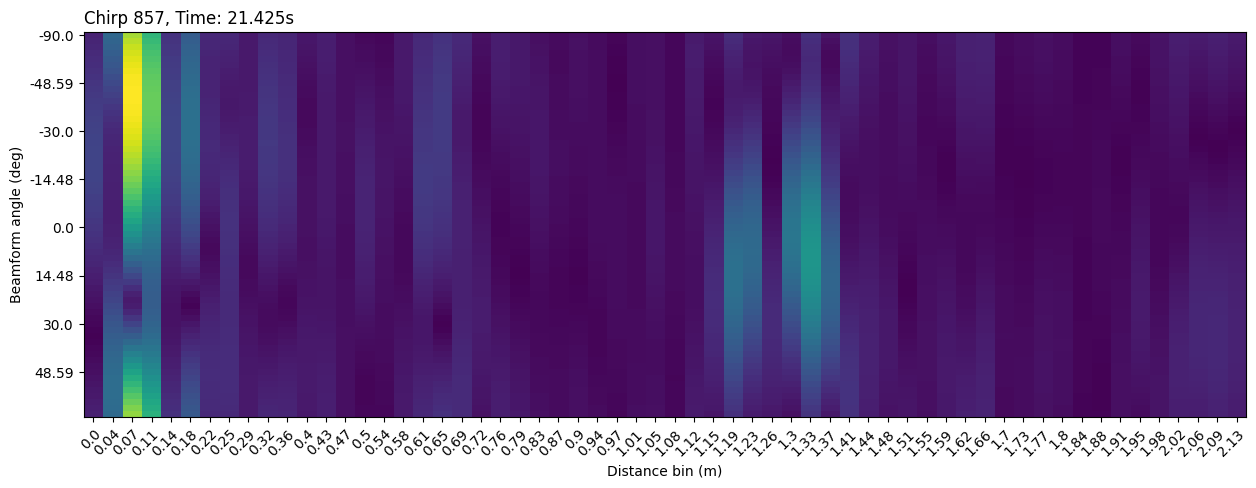

In [ ]:
# _=beamform(P.data_cube, P)